In [ ]:
import os
import io
import boto3
from PIL import Image
from dotenv import load_dotenv
import torch
from transformers import CLIPProcessor, CLIPModel

# 상위 폴더 .env 로드
load_dotenv(dotenv_path=os.path.join(os.path.dirname(__file__), '..', '.env'))

# AWS 인증 정보
AWS_ACCESS_KEY = os.environ.get('AWS_ACCESS_KEY')
AWS_SECRET_KEY = os.environ.get('AWS_SECRET_KEY')
BUCKET_NAME = os.environ.get('BUCKET_NAME')
REGION_NAME = os.environ.get('REGION_NAME')

# 저장할 로컬 폴더
LOCAL_SAVE_DIR = './interior_case_images'
os.makedirs(LOCAL_SAVE_DIR, exist_ok=True)

# S3 세션 생성
s3 = boto3.client('s3',
                  aws_access_key_id=AWS_ACCESS_KEY,
                  aws_secret_access_key=AWS_SECRET_KEY,
                  region_name=REGION_NAME)

# 이미지 파일 확장자 필터
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.webp')

# CLIP 모델 및 프로세서 로드 (처음 한 번만 다운로드 됨)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# 분류할 클래스 목록
LABELS = ["interior", "floor plan", "rendering", "other"]

def list_images_in_s3_folder(bucket, folder):
    """S3 폴더 내 이미지 파일 리스트 가져오기"""
    paginator = s3.get_paginator('list_objects_v2')
    page_iterator = paginator.paginate(Bucket=bucket, Prefix=folder)

    image_keys = []
    for page in page_iterator:
        for item in page.get('Contents', []):
            key = item['Key']
            if key.lower().endswith(VALID_EXTENSIONS):
                image_keys.append(key)

    return image_keys

def get_image_from_s3(bucket, key):
    """S3 객체를 PIL 이미지로 반환"""
    response = s3.get_object(Bucket=bucket, Key=key)
    return Image.open(io.BytesIO(response['Body'].read())).convert("RGB")

def classify_image_with_clip(image: Image.Image) -> str:
    """CLIP 모델을 사용해 이미지 분류"""
    inputs = processor(text=LABELS, images=image, return_tensors="pt", padding=True).to(device)
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image  # 이미지-텍스트 유사도
    probs = logits_per_image.softmax(dim=1)      # 확률화

    predicted_idx = probs.argmax().item()
    predicted_label = LABELS[predicted_idx]
    confidence = probs[0, predicted_idx].item()

    return predicted_label, confidence

def save_image_locally(image: Image.Image, filename: str):
    """이미지를 로컬 폴더에 저장"""
    path = os.path.join(LOCAL_SAVE_DIR, filename)
    image.save(path)
    print(f"✅ Saved: {path}")

def main():
    # S3 폴더 경로 설정 (예: 'img-normalized/512_resized_case_study_images/')
    S3_FOLDER = 'img-normalized/512_resized_case_study_images/'

    image_keys = list_images_in_s3_folder(BUCKET_NAME, S3_FOLDER)

    print(f"총 이미지 수: {len(image_keys)}")

    for key in image_keys:
        print(f"🔍 Processing: {key}")
        try:
            image = get_image_from_s3(BUCKET_NAME, key)
            label, confidence = classify_image_with_clip(image)
            print(f"   📌 Classification: {label} (Confidence: {confidence:.2f})")

            if label == 'interior':
                filename = os.path.basename(key)
                save_image_locally(image, filename)
            else:
                print(f"   ❌ Skipped (Not interior): {label}")

        except Exception as e:
            print(f"   ⚠️ Error processing {key}: {e}")

if __name__ == "__main__":
    main()


In [ ]:
import os
from openai import OpenAI
import base64, pathlib
from PIL import Image
from IPython.display import Image as IPyImage, display
from dotenv import load_dotenv

load_dotenv()

client = OpenAI(api_key=os.getenv("GOODFELLOW_OPENAI_API_KEY"))

# --- [3] 유틸: Base64 이미지 저장 ---
def save_b64(b64_string, filename):
    pathlib.Path(filename).write_bytes(base64.b64decode(b64_string))
    print(f"[✅ Saved] {filename}")

# --- [4] 입력 파일 경로 ---
# 시공 후(가구 있는) 이미지를 준비하세요.
input_image_path = "10007_00.jpg"     # 예: 시공 후 이미지
mask_image_path  = None            # 마스크를 쓸 경우 "mask.png" 로 교체

# --- [5] 프롬프트 정의 ---
prompt_text = (
    "같은 카메라 시점과 구조를 유지하면서, "
    "가구와 소품, 커튼, 전자제품 등을 모두 제거하고 "
    "벽과 바닥, 창호 질감은 그대로 유지한 빈방 이미지를 만들어줘. "
    "인위적인 흔적 없이 자연스러운 조명과 벽면을 유지해줘."
)

# --- [6] API 호출 ---
print("[🚀] Requesting image edit from OpenAI...")

if mask_image_path:
    response = client.images.edit(
        model="gpt-image-1",
        image=open(input_image_path, "rb"),
        mask=open(mask_image_path, "rb"),
        prompt=prompt_text,
        size="1024x1024",
        n=2,
    )
else:
    response = client.images.edit(
        model="gpt-image-1",
        image=open(input_image_path, "rb"),
        prompt=prompt_text,
        size="1024x1024",
        n=2,
    )

# --- [7] 결과 저장 및 표시 ---
for i, data in enumerate(response.data):
    out_file = f"empty_room_{i}.png"
    save_b64(data.b64_json, out_file)
    display(IPyImage(filename=out_file))


In [ ]:
import cv2
import numpy as np
from PIL import Image
from ultralytics import YOLO
import openai
import requests
from io import BytesIO
import tempfile
import os
from dotenv import load_dotenv

load_dotenv()

# 0. 설정
openai.api_key = os.getenv("GOODFELLOW_OPENAI_API_KEY")
IMAGE_PATH = "10007_00.jpg"  # 원본 인테리어 이미지 경로
OUTPUT_PATH = "output_no_furniture.png"

# 1. YOLOv8 모델 로드
model = YOLO("yolov8n.pt")  # 필요시 yolov8s.pt 등으로 변경 가능

# 2. 가구 감지
results = model(IMAGE_PATH)[0]

# 3. 가구 클래스 설정 (COCO 클래스 기준)
furniture_classes = [56, 57, 60, 61, 62, 63, 65, 67, 70]  # 예: chair, couch, bed 등

# 4. 원본 이미지와 빈 마스크 생성
original = cv2.imread(IMAGE_PATH)
h, w, _ = original.shape
mask = np.zeros((h, w), dtype=np.uint8)

# 5. 감지된 가구를 마스크에 흰색 박스로 표시
for box in results.boxes:
    cls = int(box.cls[0])
    if cls in furniture_classes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cv2.rectangle(mask, (x1, y1), (x2, y2), 255, -1)  # 흰색 채움

# 6. PIL 이미지로 변환 및 리사이즈 (OpenAI는 1024x1024만 지원)
original_pil = Image.fromarray(cv2.cvtColor(original, cv2.COLOR_BGR2RGB)).resize((1024, 1024))
mask_pil = Image.fromarray(mask).convert("L").resize((1024, 1024))

# 7. 임시 파일로 저장하여 OpenAI API에 전달
with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as temp_image_file, \
     tempfile.NamedTemporaryFile(suffix=".png", delete=False) as temp_mask_file:

    original_pil.save(temp_image_file.name)
    mask_pil.save(temp_mask_file.name)

    # 8. OpenAI API (DALL·E 2 Inpainting) 호출
    with open(temp_image_file.name, "rb") as image_file, open(temp_mask_file.name, "rb") as mask_file:
        response = openai.images.edit(
            image=image_file,
            mask=mask_file,
            prompt = (
                "Remove the furniture in the masked areas only. "
                "Keep the walls, floor, ceiling, and lighting exactly the same. "
                "Preserve the room’s perspective, colors, shadows, and textures."
            ),
            model="GPT-4o",  # DALL·E 3은 현재 edit 기능 미지원
            size="1024x1024",
            response_format="url",
            n=1
        )

# 9. 결과 이미지 다운로드 및 저장
result_url = response.data[0].url
result_image = Image.open(BytesIO(requests.get(result_url).content))
result_image.save(OUTPUT_PATH)

print(f"✅ 완료! 가구 제거된 이미지가 '{OUTPUT_PATH}'에 저장되었습니다.")

# 10. 임시 파일 삭제
os.remove(temp_image_file.name)
os.remove(temp_mask_file.name)


In [ ]:
import os
import openai
from dotenv import load_dotenv

load_dotenv()

openai.api_key = os.getenv("GOODFELLOW_OPENAI_API_KEY")

def remove_furniture_with_gpt4o(image_path):
    # 1. 이미지 파일 업로드 (파일 객체로)
    with open(image_path, "rb") as f:
        uploaded_file = openai.files.upload(file=f, purpose="fine-tune")  # purpose는 API 문서 확인 필요

    # 2. 업로드한 파일 ID 가져오기
    file_id = uploaded_file["id"]
    
    # 3. 멀티모달 메시지 작성 (파일 타입으로 이미지 전달)
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Please remove all furniture from this room image but keep the room structure intact."},
                {"type": "file", "file": {"id": file_id}}
            ]
        }
    ]
    
    # 4. GPT-4o 멀티모달 채팅 요청
    response = openai.chat.completions.create(
        model="gpt-4o",
        messages=messages,
    )
    
    print(response.choices[0].message.content)
    return response.choices[0].message.content

if __name__ == "__main__":
    remove_furniture_with_gpt4o("10007_00.jpg")


In [ ]:
import torch
from PIL import Image
from diffusers import AutoPipelineForInpainting
from transformers import SamModel, SamProcessor

# --- 1. 모델 로드 ---
# Inpainting 모델 (Stable Diffusion 기반 예시)
inpaint_pipeline = AutoPipelineForInpainting.from_pretrained(
    "diffusers/stable-diffusion-xl-1.0-inpainting-0.1",
    torch_dtype=torch.float16,
    variant="fp16"
).to("cuda")

# Segmentation 모델 (SAM)
sam_model = SamModel.from_pretrained("facebook/sam-vit-huge").to("cuda")
sam_processor = SamProcessor.from_pretrained("facebook/sam-vit-huge")


# --- 2. 이미지 및 마스크 준비 ---
# 원본 이미지 로드
image_path = "10007_00.jpg"
original_image = Image.open(image_path).convert("RGB")

# [중요] 이 부분에서 SAM을 사용해서 가구 마스크를 생성해야 합니다.
# 이 예시에서는 마스크가 이미 생성되었다고 가정합니다.
# mask_image는 가구 부분만 흰색, 나머지는 검은색인 이미지입니다.
mask_path = "furniture_mask.png"
mask_image = Image.open(mask_path).convert("RGB")


# --- 3. 인페인팅 실행 ---
prompt = "A clean room with no furniture, photorealistic, 4k" # 배경을 어떻게 채울지 간단한 지시

# 파이프라인 실행
result_image = inpaint_pipeline(
    prompt=prompt,
    image=original_image,
    mask_image=mask_image,
    strength=1.0, # 1.0으로 설정해야 마스크 영역을 완전히 새로 그림
    num_inference_steps=50
).images[0]


# --- 4. 결과 저장 ---
result_image.save("result_image_no_furniture.jpg")

print("가구 제거 완료!")

🛠️ GPT-4o 이미지 인페인팅 중... (마스크 없음)


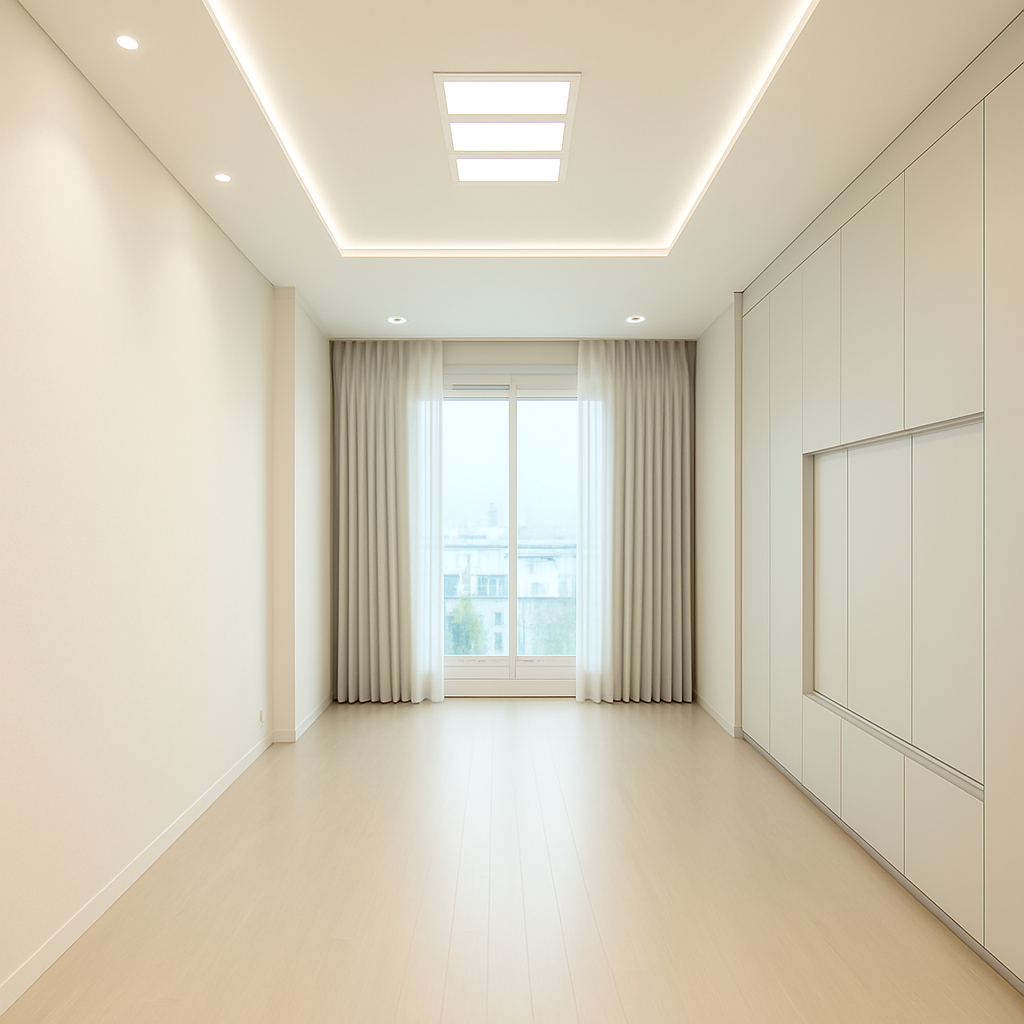

✅ 가구 제거 완료! 결과 저장 경로: result_no_furniture.png


In [2]:
import base64
import os
from openai import OpenAI
from PIL import Image
from io import BytesIO
from dotenv import load_dotenv
load_dotenv() 

client = OpenAI(api_key=os.getenv("GOODFELLOW_OPENAI_API_KEY"))

#input_image = "10007_00.jpg"
input_image = "10017_00.jpg"
output_image = "result_no_furniture.png"

print("🛠️ GPT-4o 이미지 인페인팅 중... (마스크 없음)")

response = client.images.edit(
    model="gpt-image-1",  # 또는 "gpt-4o" (이미지 편집 지원 버전)
    image=open(input_image, "rb"),
    prompt=(
        "Remove all furniture from the image and fill the background naturally. "
        "Keep walls, floor, and lighting realistic, photorealistic 4k quality."
    ),
    size="1024x1024"
)

# 결과 이미지 저장
image_base64 = response.data[0].b64_json
image_bytes = base64.b64decode(image_base64)

with open(output_image, "wb") as f:
    f.write(image_bytes)

Image.open(BytesIO(image_bytes)).show()

print(f"✅ 가구 제거 완료! 결과 저장 경로: {output_image}")
